In [16]:
# Setup and import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from scipy import stats


In [17]:
# Read csv file

df = pd.read_csv("/content/SampleSuperstore.csv")

**Step 1 - Exploratory Data Analysis**

In [18]:
# Understand structure, data types, and completeness

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9994 non-null   object 
 1   Segment       9994 non-null   object 
 2   Country       9994 non-null   object 
 3   City          9994 non-null   object 
 4   State         9994 non-null   object 
 5   Postal Code   9994 non-null   int64  
 6   Region        9994 non-null   object 
 7   Category      9994 non-null   object 
 8   Sub-Category  9994 non-null   object 
 9   Sales         9994 non-null   float64
 10  Quantity      9994 non-null   int64  
 11  Discount      9994 non-null   float64
 12  Profit        9994 non-null   float64
dtypes: float64(3), int64(2), object(8)
memory usage: 1015.1+ KB


In [19]:
# Get statistical summary to detect anomalies or skewness

df.describe()

,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,55190.379428,229.858001,3.789574,0.156203,28.656896
std,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,90008.000000,209.940000,5.000000,0.200000,29.364000
max,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [20]:
# Identify missing values, if present, it can break the predictive model

df.isnull().sum()

,0
Ship Mode,0
Segment,0
Country,0
City,0
State,0
Postal Code,0
Region,0
Category,0
Sub-Category,0
Sales,0


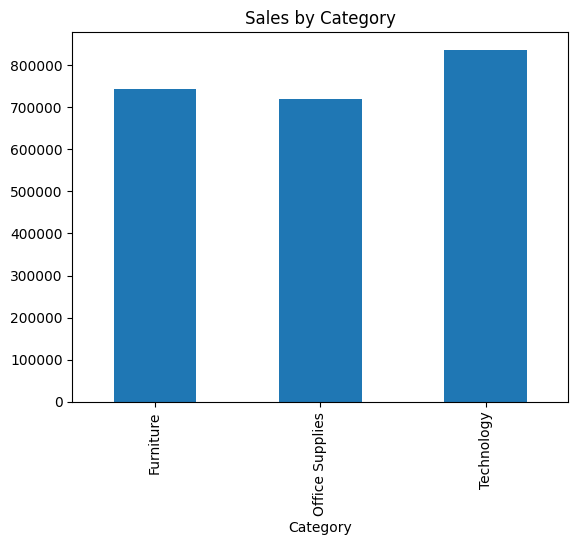

In [21]:
# Understand which categories generate the most revenue

df.groupby("Category")["Sales"].sum().plot(kind='bar')
plt.title("Sales by Category")
plt.show()

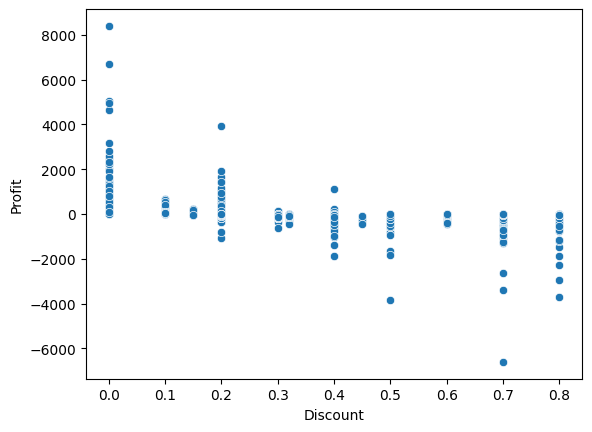

In [22]:
# Check relationship between discount and profit (business critical)

sns.scatterplot(x = "Discount", y = "Profit", data = df)
plt.show()

**Step 2 : Python Concepts (Loops, Functions, String slicing)**

In [23]:
# String slicing

df['City'] = df['City'].astype(str)

# Extracting first 3 letters from City and storing them in a new column as a prefix

df['City_prefix'] = df['City'].apply(lambda x: x[:3].upper())

df['City_prefix'].unique()

array(['HEN', 'LOS', 'FOR', 'CON', 'SEA', 'MAD', 'WES', 'SAN', 'FRE',
       'PHI', 'ORE', 'HOU', 'RIC', 'NAP', 'MEL', 'EAG', 'DOV', 'NEW',
       'TRO', 'CHI', 'GIL', 'SPR', 'JAC', 'MEM', 'DEC', 'DUR', 'COL',
       'ROC', 'MIN', 'POR', 'SAI', 'AUR', 'CHA', 'ORL', 'URB', 'BRI',
       'WIL', 'BLO', 'PHO', 'ROS', 'IND', 'PAS', 'FRA', 'SCO', 'EDM',
       'CAR', 'MON', 'FAI', 'GRA', 'RED', 'HAM', 'AKR', 'DEN', 'DAL',
       'WHI', 'SAG', 'MED', 'DUB', 'DET', 'TAM', 'LAK', 'BRE', 'MOR',
       'CIN', 'ING', 'BEL', 'TAY', 'ARL', 'ARV', 'HAC', 'LON', 'HES',
       'MUR', 'LAY', 'AUS', 'LOW', 'MAN', 'HAR', 'TUC', 'QUI', 'PEM',
       'DES', 'PEO', 'LAS', 'WAR', 'MIA', 'HUN', 'LOU', 'LAW', 'CAN',
       'GAS', 'AUB', 'NOR', 'PAR', 'AMA', 'LIN', 'FAY', 'COS', 'ATL',
       'GLA', 'GRE', 'MES', 'ANA', 'MAR', 'SAL', 'LAR', 'GRO', 'DEA',
       'VAL', 'MIS', 'PLA', 'SIE', 'VAN', 'CLE', 'TYL', 'BUR', 'WAY',
       'CHE', 'PAL', 'MOU', 'HIA', 'OCE', 'EVA', 'TRE', 'COT', 'BOS',
       'LAN', 'ASH',

In [24]:
# Custom Function Pracitce to define the profit classification column as Profit, Loss, Breakeven

def profit_flag(profit_value):
  if profit_value > 0:
    return 'Profit'
  elif profit_value == 0:
    return 'Breakeven'
  else:
    return 'Loss'

# Cast the function on to the existing column to create a new column

df['Profit_classification'] = df['Profit'].apply(profit_flag)

In [25]:
df.head(20)

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit,City_prefix,Profit_classification
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136,HEN,Profit
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820,HEN,Profit
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714,LOS,Profit
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310,FOR,Loss
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164,FOR,Profit
5,Standard Class,Consumer,United States,Los Angeles,California,90032,West,Furniture,Furnishings,48.8600,7,0.00,14.1694,LOS,Profit
6,Standard Class,Consumer,United States,Los Angeles,California,90032,West,Office Supplies,Art,7.2800,4,0.00,1.9656,LOS,Profit
7,Standard Class,Consumer,United States,Los Angeles,California,90032,West,Technology,Phones,907.1520,6,0.20,90.7152,LOS,Profit
8,Standard Class,Consumer,United States,Los Angeles,California,90032,West,Office Supplies,Binders,18.5040,3,0.20,5.7825,LOS,Profit
9,Standard Class,Consumer,United States,Los Angeles,California,90032,West,Office Supplies,Appliances,114.9000,5,0.00,34.4700,LOS,Profit


In [26]:
# Iterate for loop across segments to generate business insights such as sales/profit per segment
for seg in df['Segment'].unique():
    temp = df[df['Segment'] == seg]
    print(f"{seg} -> Sales: {temp['Sales'].sum()}, Profit: {temp['Profit'].sum()}")

Consumer -> Sales: 1161401.3449999997, Profit: 134119.2092
Corporate -> Sales: 706146.3668, Profit: 91979.13399999999
Home Office -> Sales: 429653.1485, Profit: 60298.678499999995


**Step 3 (Feature Engineering)**

In [27]:
#Sales per unit

df['Sales_per_unit'] = df['Sales']/df['Quantity']

#Profit per unit

df['Profit_per_unit'] = df['Profit']/df['Quantity']

#Reviewing dataset with multiple filter conditions

df_filtered = df[
    (df['Ship Mode'] == 'Second Class') &
    (df['Profit'] > 0 ) &
    (df['Discount'] < 0.3)
]

df_filtered.head(10)

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit,City_prefix,Profit_classification,Sales_per_unit,Profit_per_unit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.960,2,0.0,41.9136,HEN,Profit,130.980,20.9568
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.940,3,0.0,219.5820,HEN,Profit,243.980,73.1940
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.620,2,0.0,6.8714,LOS,Profit,7.310,3.4357
17,Second Class,Consumer,United States,West Jordan,Utah,84084,West,Office Supplies,Storage,55.500,2,0.0,9.9900,WES,Profit,27.750,4.9950
18,Second Class,Consumer,United States,San Francisco,California,94109,West,Office Supplies,Art,8.560,2,0.0,2.4824,SAN,Profit,4.280,1.2412
19,Second Class,Consumer,United States,San Francisco,California,94109,West,Technology,Phones,213.480,3,0.2,16.0110,SAN,Profit,71.160,5.3370
20,Second Class,Consumer,United States,San Francisco,California,94109,West,Office Supplies,Binders,22.720,4,0.2,7.3840,SAN,Profit,5.680,1.8460
25,Second Class,Consumer,United States,Los Angeles,California,90049,West,Office Supplies,Binders,11.648,2,0.2,4.2224,LOS,Profit,5.824,2.1112
26,Second Class,Consumer,United States,Los Angeles,California,90049,West,Technology,Accessories,90.570,3,0.0,11.7741,LOS,Profit,30.190,3.9247
34,Second Class,Home Office,United States,Houston,Texas,77095,Central,Office Supplies,Paper,29.472,3,0.2,9.9468,HOU,Profit,9.824,3.3156


**Step 4 (A/B Testing)**

In [42]:
# Compare profitability of high vs low discount strategies

df['discount_group'] = np.where(df['Discount'] > 0.2, 'High', 'Low')

# Way to store a dataframe filtered column as pandas series for further AB Testing
group_high = df[df['discount_group'] == 'High']['Profit']
group_low = df[df['discount_group'] == 'Low']['Profit']

# Ways to fetch only single column and multiple columns from dataframe based on filter values
group_high_df = df[df['discount_group'] == 'High'][['Profit']]
group_high_multiple_col = df[df['discount_group'] == 'High'][['Profit', 'Sales']]

from scipy import stats
t_stat, p_value = stats.ttest_ind(group_high, group_low)

print(f"P-value: {p_value:.4f} | {'Significant' if p_value < 0.05 else 'Not Significant'} | "
      f"{'H1: Discount impacts profit' if p_value < 0.05 else 'H0: No impact'}")

P-value: 0.0000 | Significant | H1: Discount impacts profit


**Step 5 - Answering Business Questions**

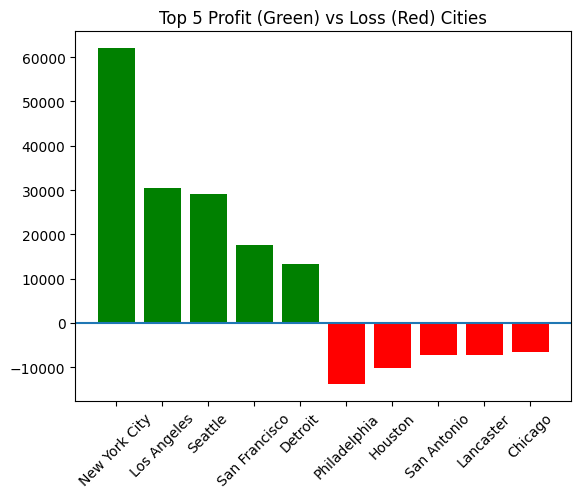

In [39]:
# Which top 5 cities are profitable vs loss-making?

df_city_sales = df.groupby('City').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Discount': 'mean',
    'Quantity': 'sum'
}).reset_index()

# Get top 5 profitable cities
top_profit = df_city_sales.sort_values(by='Profit', ascending=False).head(5)

# Get top 5 loss-making cities
top_loss = df_city_sales.sort_values(by='Profit', ascending=True).head(5)

# Combine both datasets for visualization
top_cities = pd.concat([top_profit, top_loss])

# Color code profit vs loss
colors = ['green' if x > 0 else 'red' for x in top_cities['Profit']]

plt.figure()
plt.bar(top_cities['City'], top_cities['Profit'], color=colors)
plt.axhline(0)
plt.xticks(rotation=45)

plt.title("Top 5 Profit (Green) vs Loss (Red) Cities")
plt.show()